R2 Score: 0.8947656211855464
MSE: 0.07454813483800973

Classification Accuracy: 88.18181818181819


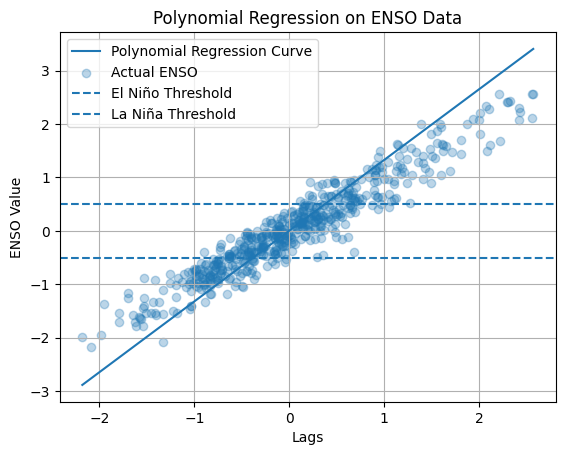

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# -------------------------------
# Load Data
# -------------------------------
file = "nino-3.4_7924_noaa.txt"
data = pd.read_csv(file, sep='\s+', header=None)

values = data.values.flatten()
values = values[values > -90]

df = pd.DataFrame(values, columns=["ENSO"])

# -------------------------------
# Feature Engineering
# -------------------------------
df["lag1"] = df["ENSO"].shift(1)
df["lag2"] = df["ENSO"].shift(2)

df = df.dropna()

# -------------------------------
# Polynomial Features
# -------------------------------
X = df[["lag1", "lag2"]]
y = df["ENSO"]

poly = PolynomialFeatures(degree=2)   # try degree=3 later
X_poly = poly.fit_transform(X)

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# -------------------------------
# Model Training
# -------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -------------------------------
# Predictions
# -------------------------------
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# -------------------------------
# Convert to Classes
# -------------------------------
def classify(x):
    if x < -0.5:
        return 0
    elif x > 0.5:
        return 2
    else:
        return 1

y_test_class = y_test.apply(classify)
y_pred_class = pd.Series(y_pred).apply(classify)

print("\nClassification Accuracy:",
      accuracy_score(y_test_class, y_pred_class) * 100)

# -------------------------------
# Visualization
# -------------------------------
lag1_range = np.linspace(df["lag1"].min(), df["lag1"].max(), 200)
lag2_mean = df["lag2"].mean()

X_plot = pd.DataFrame({
    "lag1": lag1_range,
    "lag2": lag2_mean
})

X_plot_poly = poly.transform(X_plot)
y_plot = model.predict(X_plot_poly)

plt.figure()

# Regression curve
plt.plot(lag1_range, y_plot, label="Polynomial Regression Curve")

# Scatter actual ENSO values
plt.scatter(df["lag1"], df["ENSO"], alpha=0.3, label="Actual ENSO")

# Threshold lines
plt.axhline(0.5, linestyle='--', label="El Niño Threshold")
plt.axhline(-0.5, linestyle='--', label="La Niña Threshold")

plt.xlabel("Lags")
plt.ylabel("ENSO Value")
plt.title("Polynomial Regression on ENSO Data")
plt.legend()
plt.grid()

plt.show()

C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_24840\344046519.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  enso = pd.read_csv(enso_file, delim_whitespace=True, header=None)


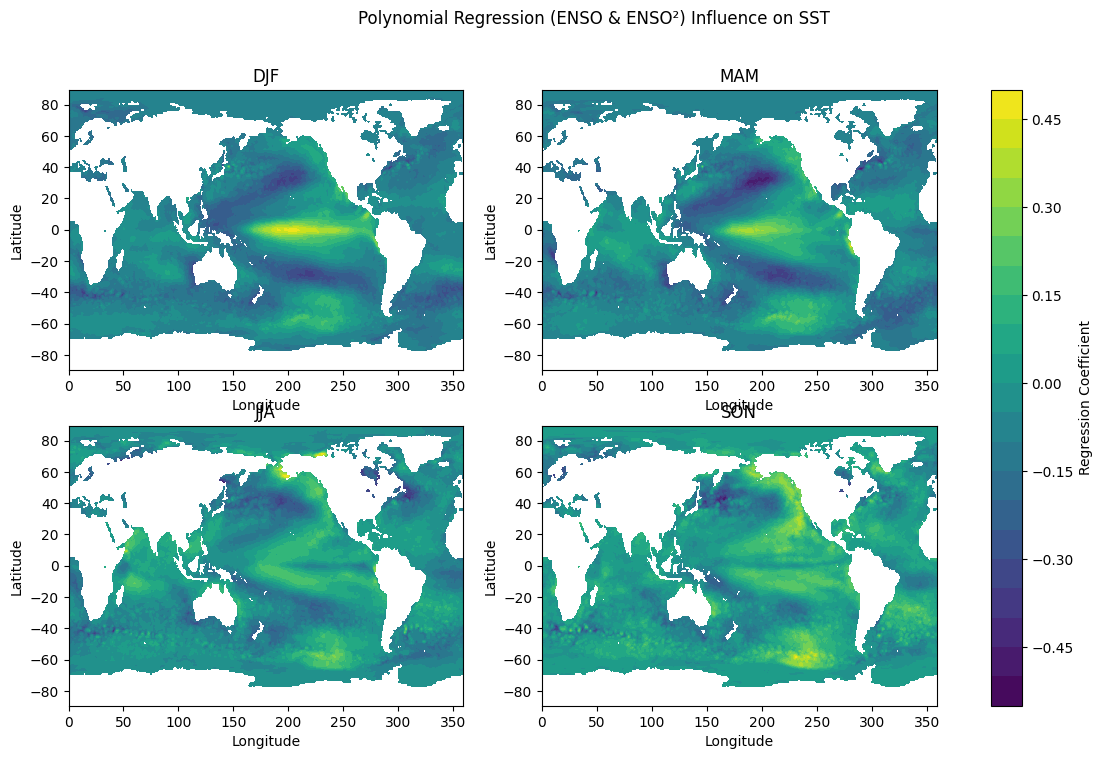

In [2]:
#Polynomal regression
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Load ENSO data
enso_file = "nino-3.4_7924_noaa.txt"
enso = pd.read_csv(enso_file, delim_whitespace=True, header=None)

enso_index = enso.iloc[:,1].values

# Convert yearly ENSO → monthly
enso_monthly = np.repeat(enso_index, 12)

# Load SST dataset
sst_file = "ERA5_SST_sst_K_monmean_7924_1.nc"
ds = xr.open_dataset(sst_file)

sst = ds["sst"]
time = ds["time"]
lat = ds["lat"]
lon = ds["lon"]

# Match ENSO length
enso_monthly = enso_monthly[:len(time)]
ds["enso"] = (("time"), enso_monthly)

# Define seasons
seasons = {
    "DJF":[12,1,2],
    "MAM":[3,4,5],
    "JJA":[6,7,8],
    "SON":[9,10,11]
}

# Polynomial transformer
poly = PolynomialFeatures(degree=2, include_bias=False)

# Create subplot figure
fig, axes = plt.subplots(2,2, figsize=(14,8))
axes = axes.flatten()

# Seasonal regression
for idx,(season, months) in enumerate(seasons.items()):

    season_ds = ds.sel(time=ds["time"].dt.month.isin(months))

    enso_vals = season_ds["enso"].values
    sst_vals  = season_ds["sst"].values

    slope_linear = np.zeros((len(lat), len(lon)))
    slope_quad   = np.zeros((len(lat), len(lon)))  # NEW

    for i in range(len(lat)):
        for j in range(len(lon)):

            y = sst_vals[:, i, j]

            if np.isnan(y).any():
                slope_linear[i,j] = np.nan
                slope_quad[i,j]   = np.nan
                continue

            X = enso_vals.reshape(-1,1)

            # Polynomial Features(Regression)
            X_poly = poly.fit_transform(X)  
            # Columns → [ENSO, ENSO^2]

            model = LinearRegression()
            model.fit(X_poly, y)
            
            #Slope of beta values
            beta = model.coef_

            slope_linear[i,j] = beta[0]   # ENSO
            slope_quad[i,j]   = beta[1]   # ENSO^2

    ax = axes[idx]

    # You can choose what to plot:
    c_linear = ax.contourf(lon, lat, slope_linear, 20)
    # OR:
    # c = ax.contourf(lon, lat, slope_quad, 20)

    ax.set_title(season)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Polynomial Regression (ENSO & ENSO²) Influence on SST")

fig.colorbar(c_linear, ax=axes.ravel().tolist(), label="Regression Coefficient")

plt.show()